In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

import joblib
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = sns.load_dataset("titanic")

In [5]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
df.shape

(891, 15)

In [7]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [8]:
df = df[[
    "survived",
    "pclass",
    "sex",
    "age",
    "fare",
    "embarked",
    "sibsp",
    "parch",
    "class",
    "who",
    "alone"
]]

In [9]:
df["family_size"] = (
    df["sibsp"] +
    df["parch"] + 1
)


In [10]:
df["fare_per_person"] = (
    df["fare"] /
    df["family_size"]
)

In [11]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=[
        "Child",
        "Teen",
        "YoungAdult",
        "Adult",
        "Senior"
    ]
)

In [12]:
X = df.drop("survived", axis=1)
y = df["survived"]

In [13]:
numeric_features = [
    "age",
    "fare",
    "sibsp",
    "parch",
    "family_size",
    "fare_per_person"
]

categorical_features = [
    "sex",
    "embarked",
    "class",
    "who",
    "alone",
    "age_group"
]

In [14]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),

    (
        "scaler",
        StandardScaler()
    )
])

In [15]:
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),

    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

In [16]:
preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        numeric_features
    ),

    (
        "cat",
        categorical_pipeline,
        categorical_features
    )
])

In [17]:
pipeline = Pipeline([
    (
        "preprocessing",
        preprocessor
    ),

    (
        "model",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=6,
            random_state=42
        )
    )
])

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
predictions = pipeline.predict(X_test)

In [21]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print("MODEL ACCURACY:", accuracy)

MODEL ACCURACY: 0.8100558659217877


In [22]:
report = classification_report(
    y_test,
    predictions
)

print("MODEL REPORT:\n", report)

MODEL REPORT:
               precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



[]

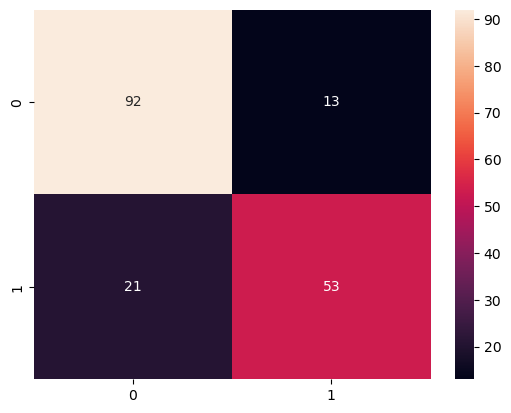

In [23]:
sns.heatmap(
    confusion_matrix(
        y_test,
        predictions
    ),
    annot=True
)
plt.plot()

In [24]:
joblib.dump(
    pipeline,
    "titanic_pipeline.pkl"
)

['titanic_pipeline.pkl']

In [26]:
processed_data = preprocessor.fit_transform(X)

In [27]:
# Convert sparse matrix to dense if needed
processed_df = pd.DataFrame(
    processed_data.toarray()
    if hasattr(processed_data, "toarray")
    else processed_data
)

In [28]:
processed_df["target"] = y.values

processed_df.to_parquet(
    "processed_titanic.parquet",
    index=False,
    compression="snappy"
)

print("Processed Dataset Saved as Parquet")

Processed Dataset Saved as Parquet


In [29]:
loaded_pipeline = joblib.load(
    "titanic_pipeline.pkl"
)

In [30]:
new_data = pd.DataFrame([
    {
        "pclass": 1,
        "sex": "female",
        "age": 28,
        "fare": 100,
        "embarked": "S",
        "sibsp": 0,
        "parch": 0,
        "class": "First",
        "who": "woman",
        "alone": True,
        "family_size": 1,
        "fare_per_person": 100,
        "age_group": "YoungAdult"
    }
])


In [31]:
prediction = loaded_pipeline.predict(new_data)

print("\nNew Passenger Prediction:")

if prediction[0] == 1:
    print("Survived")
else:
    print("Did Not Survive")


New Passenger Prediction:
Survived
